# Imbalanced Classification with SMOTE

Detects air pressure system failures in Scania trucks from 170 anonymized sensor readings, where failures are 1.67% of the training set. Every model is fit twice, once ignoring the imbalance and once correcting for it, and judged on missed failures rather than on accuracy. Class weighting cuts false negatives from 121 to 35; SMOTE cuts them from 89 to 51.

**Data:** APS Failure at Scania Trucks; 60,000 training and 16,000 test instances, 170 features; UCI Machine Learning Repository
https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks

## Models
| Model | Section | What it does |
|---|---|---|
| Mean imputer | Missing value imputation | Fills missing values across all 170 features |
| Random forest, uncorrected | Random forest | No imbalance handling; out-of-bag error against test error |
| Random forest, class-weighted | Class-weighted forest | Balanced class weights, otherwise the same configuration |
| XGBoost, L1-penalized | XGBoost | Penalty tuned by 5-fold stratified cross-validation |
| XGBoost with SMOTE | XGBoost with SMOTE | Oversampling inside the cross-validation pipeline; final fit on the resampled training set |

## Contents
| Section | What it covers |
|---|---|
| Missing value imputation | Mean imputation across all 170 features |
| Feature screening | Coefficient of variation ranking, correlation matrix, and plots for the top 13 features |
| Class balance | 59,000 negative against 1,000 positive instances in the training set |
| Random forest | Depth-10 forest with no imbalance correction; out-of-bag error against test error |
| Class-weighted forest | The same forest with balanced class weights, and the resulting shift in the confusion matrix |
| XGBoost | L1 penalty tuned by 5-fold stratified cross-validation |
| XGBoost with SMOTE | Minority oversampling applied inside the cross-validation pipeline |
| Comparison | Test error and AUC set against false negative count for each model |

## 1. Tree-Based Methods

Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn import svm

### (a) Download the APS Failure data

Download the APS Failure and Operational Data for Scania Trucks from:
https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks

The dataset contains operational data collected from heavy Scania trucks. Each instance
represents one truck, described by 170 anonymized numerical features and one class label. The training set has 60,000 instances and the
test set has 16,000. Missing values are denoted by `na`.

| Variable Name | Description | Type |
| :--- | :--- | :--- |
| **class** | Whether the truck has an APS-related failure (target variable). | `pos` (APS failure), `neg` (non-APS failure) |
| **aa_000 – eg_000** | Anonymized operational sensor readings (counters and histogram bins). | Integer / Real |

In [3]:
train_og_df = pd.read_csv('data/aps_failure_training_set.csv', na_values='na', skiprows=20, header=0)
test_og_df = pd.read_csv('data/aps_failure_test_set.csv',  na_values='na', skiprows=20, header=0)

print(f"Test data shape: {test_og_df.shape}")
print(f"Train data shape: {train_og_df.shape}")
display(train_og_df.head())


Test data shape: (16000, 171)
Train data shape: (60000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


### (b) Data Preparation

#### (i) Types of techniques used for dealing with data with missing values
Source: https://mike-data-analysis.share.connect.posit.cloud/methods-for-handling-missing-data.html

- **Mean / Median / Mode Imputation:** Replaces missing values with the column mean, median, or mode computed from observed data.
- **Linear Regression Imputation:** Predicts missing values by fitting a linear regression model using other features as predictors.
- **Logistic Regression Imputation:** Same idea as linear regression but for categorical variables, predicting the missing category from other features.
- **K-Nearest Neighbors (KNN) Imputation:** Finds the k most similar rows and fills missing values using their weighted average (continuous) or mode (categorical).
- **Multiple Imputation by Chained Equations (MICE):** Iteratively models each feature with missing values as a function of all others, repeating until estimates converge.

In [4]:
train_og_df['class'] = (train_og_df['class'] == 'pos').astype(int)
test_og_df['class']  = (test_og_df['class'] == 'pos').astype(int)

X_train_og = train_og_df.drop(columns=['class'])
y_train = train_og_df['class']
X_test_og = test_og_df.drop(columns=['class'])
y_test = test_og_df['class']

impute_train = SimpleImputer(strategy='mean')
impute_test = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(impute_train.fit_transform(X_train_og), columns=X_train_og.columns, index=X_train_og.index)
X_test = pd.DataFrame(impute_test.fit_transform(X_test_og), columns=X_test_og.columns, index=X_test_og.index)

display(X_train.head())

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,76698.0,0.713189,2.130706e+09,280.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,33058.0,0.713189,0.000000e+00,190620.639314,0.0,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,41040.0,0.713189,2.280000e+02,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,12.0,0.000000,7.000000e+01,66.000000,0.0,10.0,0.0,0.0,0.0,318.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,60874.0,0.713189,1.368000e+03,458.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


#### (ii) Calculate the Coefficient of Variation $CV$ for each feature, where $CV = \frac{s}{m}$
($ s =$  sample standard deviation; $ m =$ is sample mean)

,Mean,Std,CV
cs_009,7.791978e+02,1.833278e+05,235.277605
cf_000,1.902218e+05,3.504515e+07,184.233092
co_000,1.905156e+05,3.504515e+07,183.949017
ad_000,1.906206e+05,3.504515e+07,183.847620
dh_000,4.707073e+03,5.412428e+05,114.984991
...,...,...,...
bo_000,5.131478e+05,2.373636e+05,0.462564
bp_000,5.513898e+05,2.348736e+05,0.425967
bq_000,5.828713e+05,2.326773e+05,0.399192
br_000,6.048866e+05,2.314713e+05,0.382669


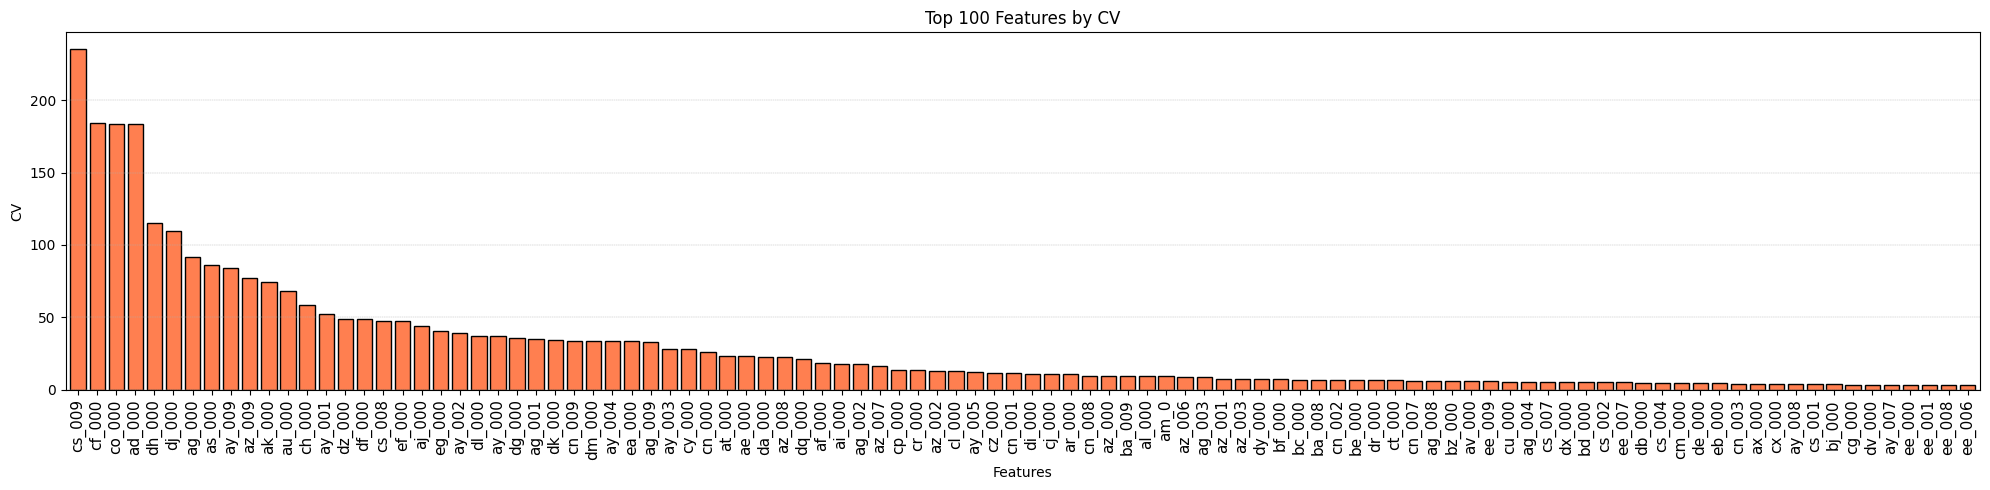

In [5]:
std_feat = X_train.std()
mean_feat = X_train.mean()
cv_feat = std_feat / mean_feat

cv_df = pd.DataFrame({'Mean': mean_feat, 'Std': std_feat, 'CV': cv_feat})
cv_df_sort = cv_df.sort_values(by='CV', ascending=False)
display(cv_df_sort)

top_100_cv = cv_df_sort.head(100)

plt.figure(figsize=(20, 5))
top_100_cv['CV'].plot(kind='bar', color='coral', edgecolor='black', width=0.8)
plt.title('Top 100 Features by CV')
plt.xlabel('Features')
plt.ylabel('CV')
plt.xticks(fontsize=11)
plt.grid(axis='y', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

#### (iii) Plot a correlation matrix

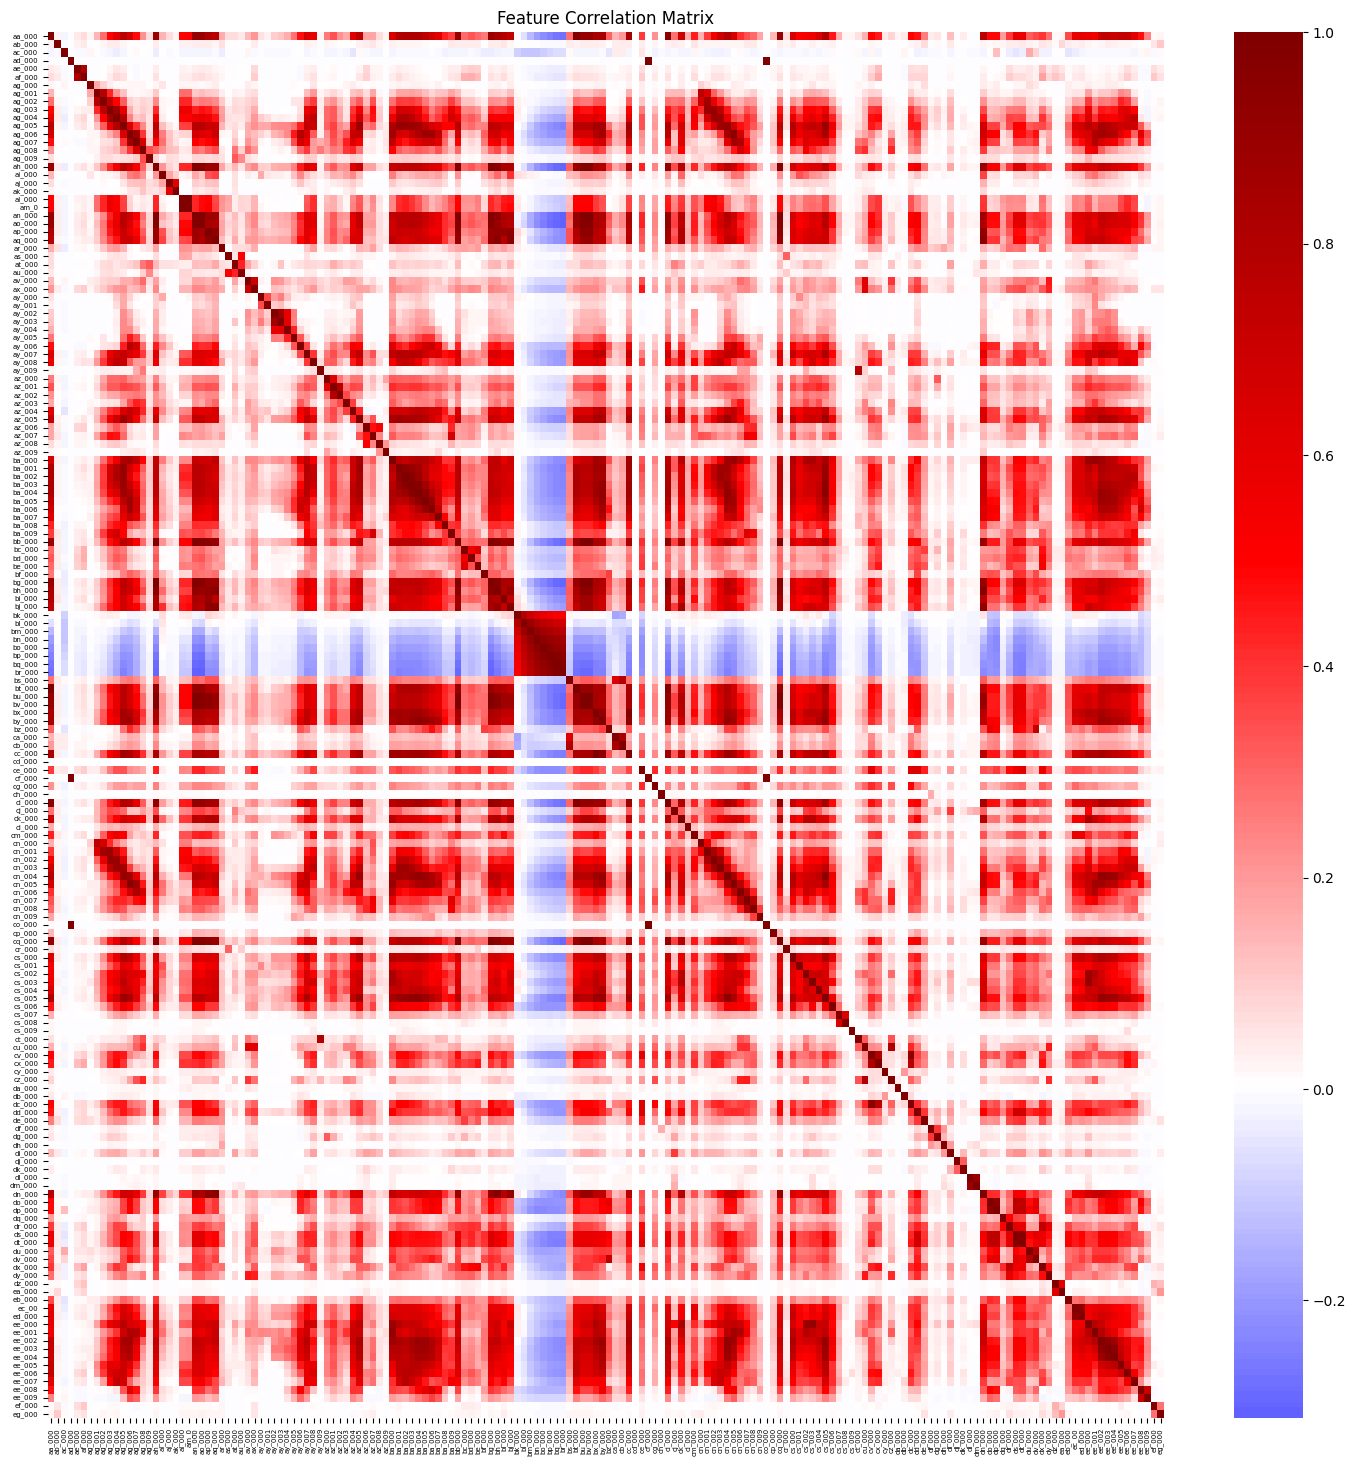

In [6]:
corr_m = X_train.corr()
plt.figure(figsize=(18, 18))
sns.heatmap(corr_m, cmap='seismic', center=0, xticklabels=True, yticklabels=True)
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)
plt.title('Feature Correlation Matrix')
plt.show()

#### (iv) Pick $\lfloor\sqrt{170}\rfloor$ features with highest CV, and make scatter plots and box plots for them.

Highest 13 CV features: ['cs_009', 'cf_000', 'co_000', 'ad_000', 'dh_000', 'dj_000', 'ag_000', 'as_000', 'ay_009', 'az_009', 'ak_000', 'au_000', 'ch_000'] 



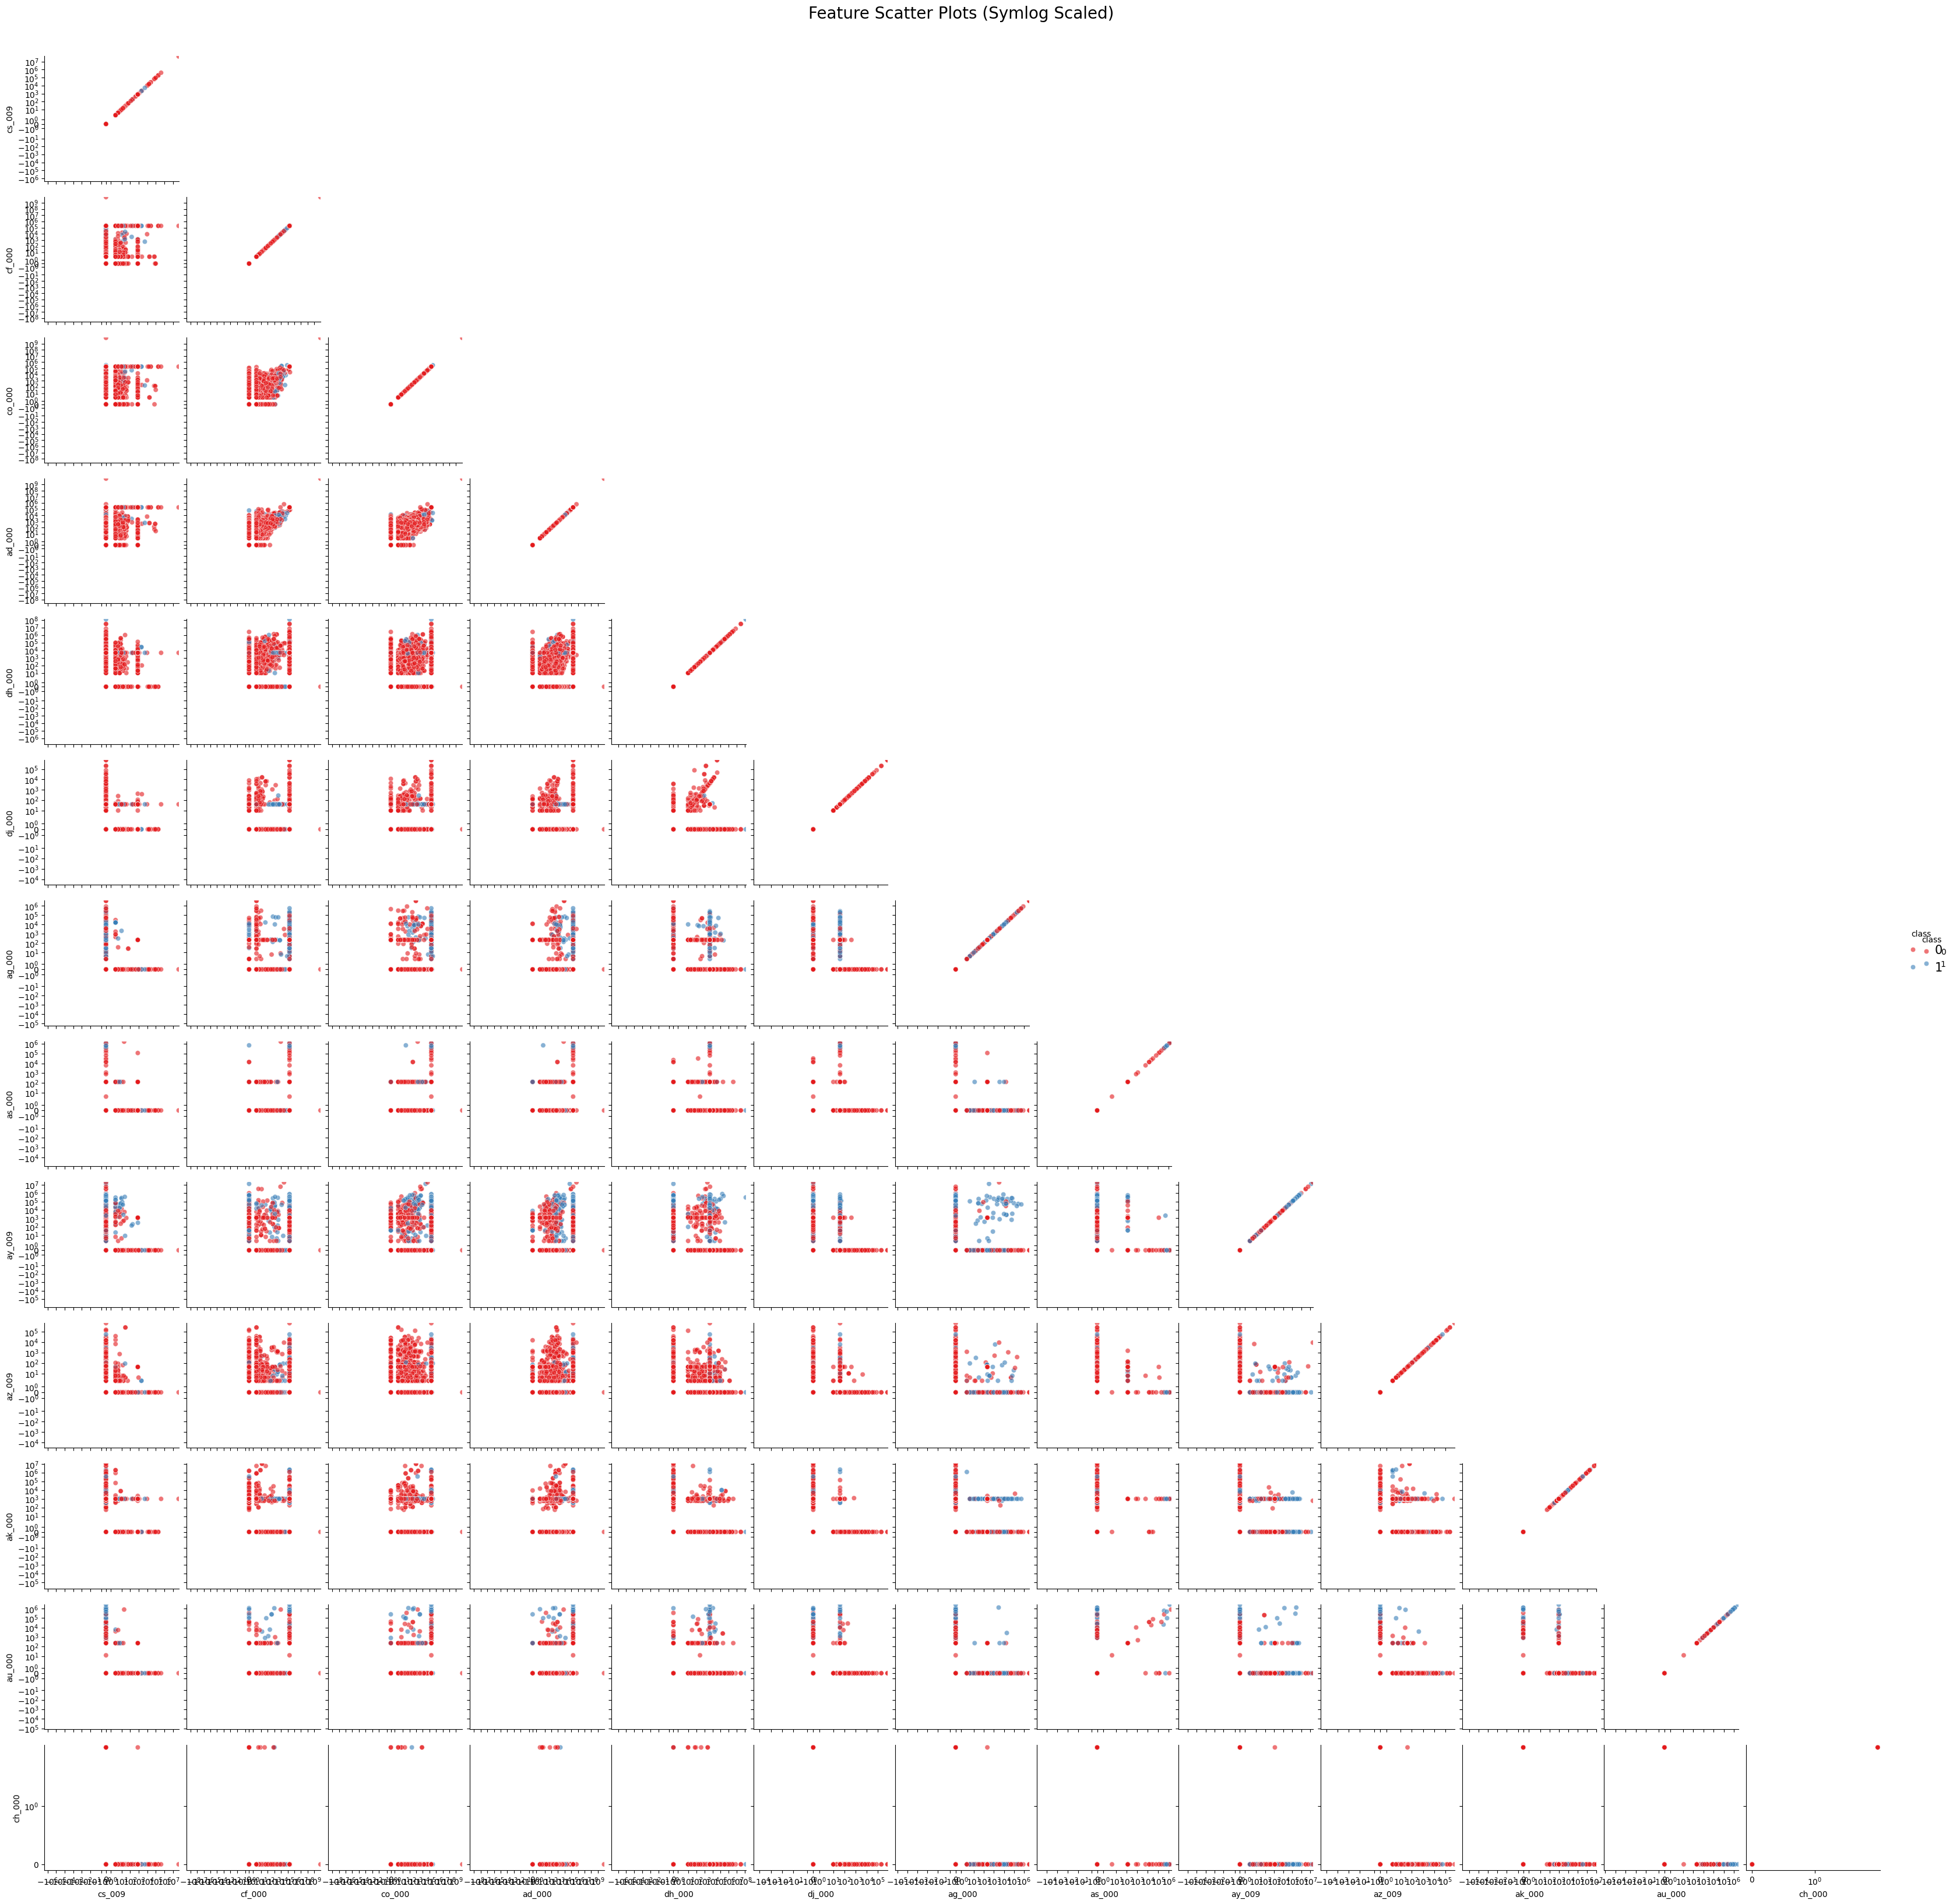

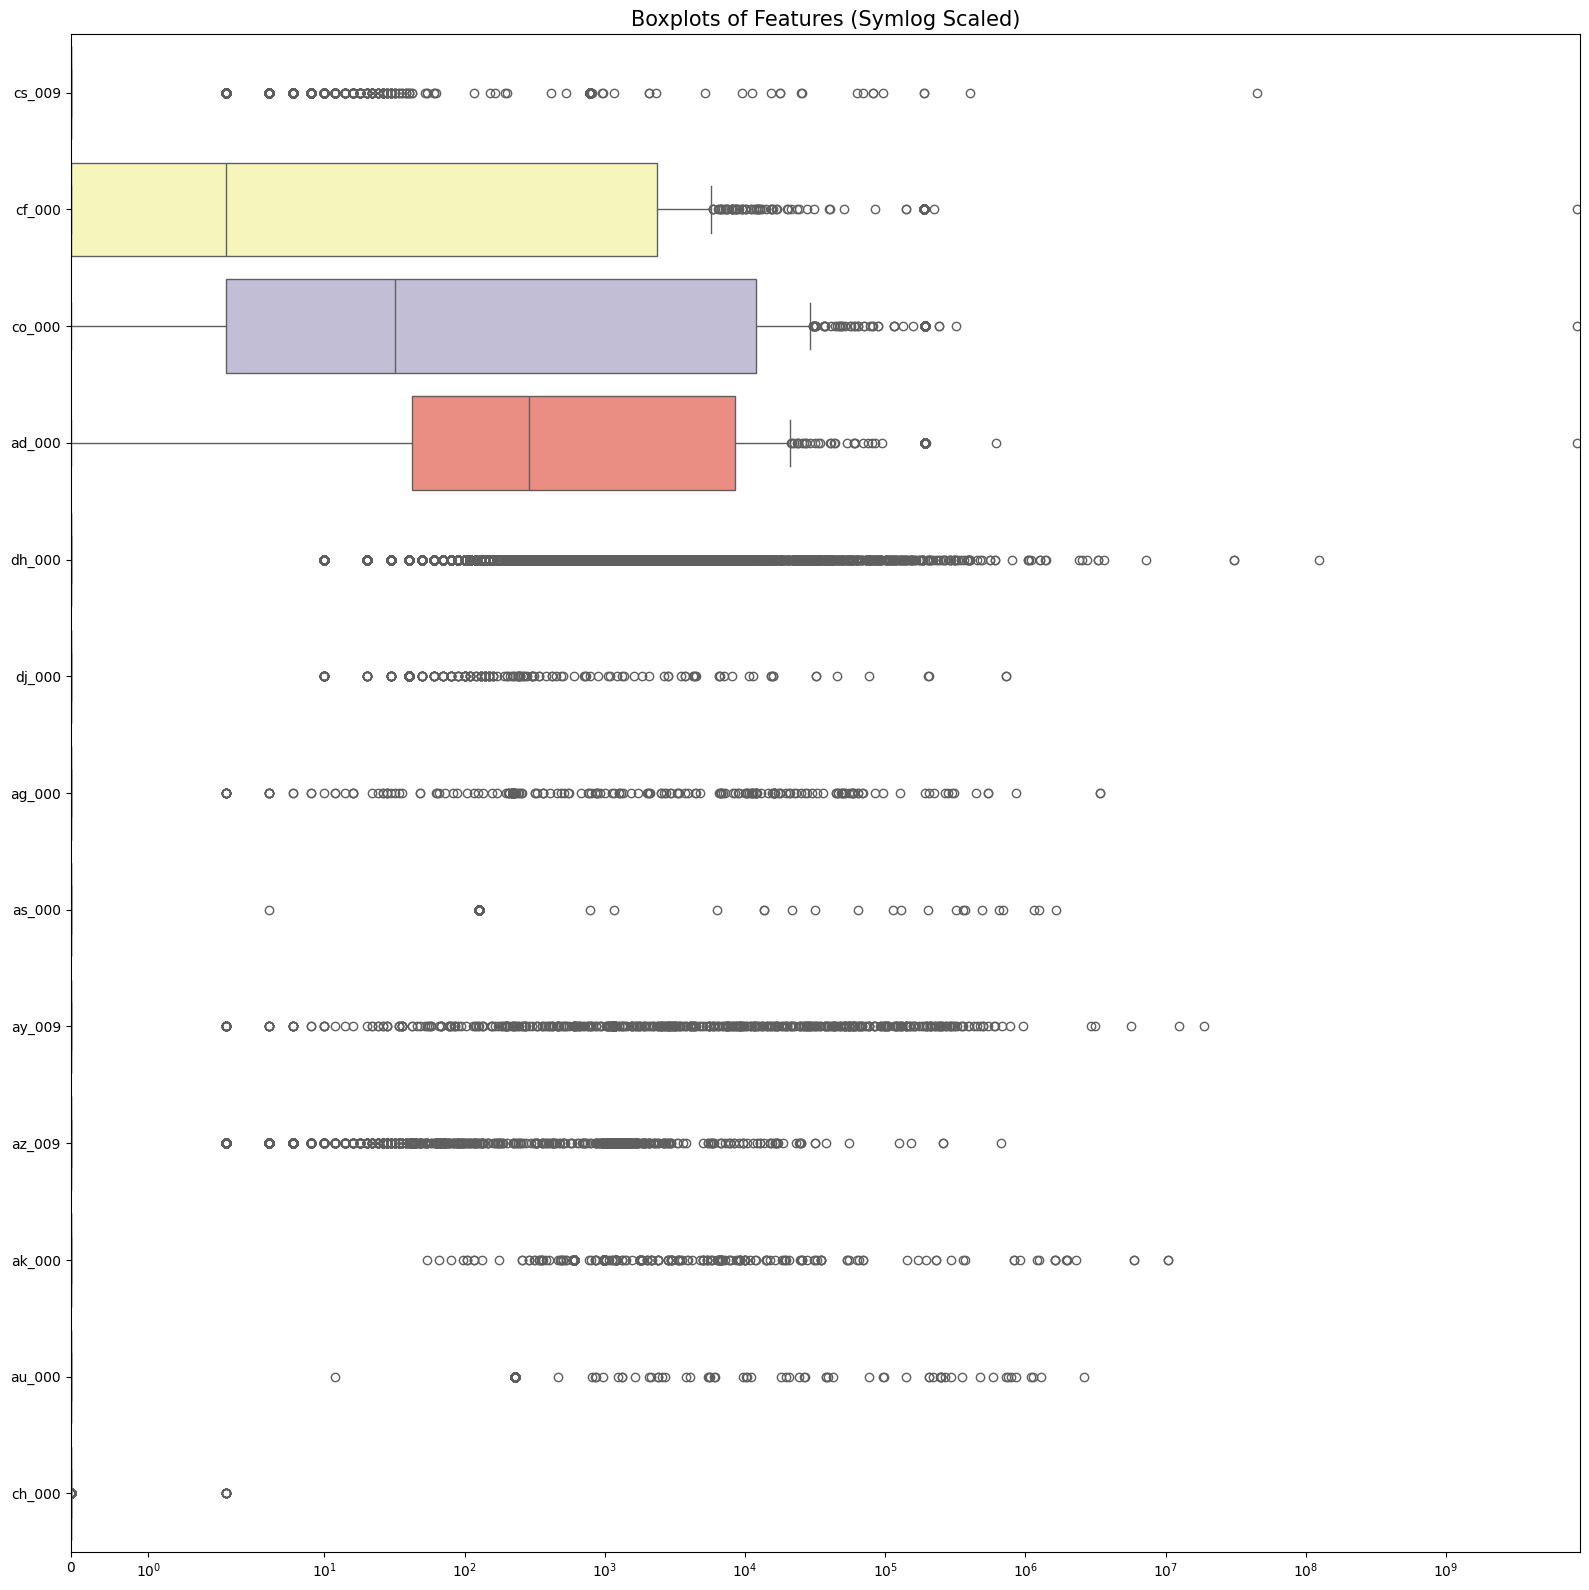

In [29]:
n = int(np.floor(np.sqrt(170)))
cv_n_feat = cv_df_sort.head(n).index.tolist()
print(f"Highest {n} CV features: {cv_n_feat} \n")

X_cv_feat_with_y = X_train[cv_n_feat].copy()
X_cv_feat_with_y["class"] = y_train

plt_feat = sns.pairplot(X_cv_feat_with_y, vars=cv_n_feat, hue="class", palette='Set1', plot_kws={'alpha':0.6}, diag_kind=None, corner=True)
plt_feat.set(xscale="symlog", yscale="symlog")
plt.suptitle('Feature Scatter Plots (Symlog Scaled)', y=1.01, fontsize=20)
plt_feat.add_legend(fontsize=15, title_fontsize=18)
plt.show()

plt.figure(figsize=(16, 16))
sns.boxplot(data=X_train[cv_n_feat], orient='h', palette='Set3')
plt.xscale('symlog')
plt.xlim(left=0)
plt.title('Boxplots of Features (Symlog Scaled)', fontsize=15)
plt.tight_layout()
plt.show()

**Overall no clear conclusion can be drawn from plots and class separation is weak from visuals alone.**
- Most features show near-zero median and all features are heavily right-skewed with extreme outliers

#### (v) Is this data set imbalanced?

In [8]:
print('Class count in Train set:')
class_train_count = y_train.value_counts()
class_train_pct = y_train.value_counts(normalize=True) * 100

train_counts = pd.DataFrame({'Count': class_train_count, 'Pct.': class_train_pct.round(2)})
train_counts.index = [0,1]
display(train_counts)


print('Class count in Test set:')
class_test_count = y_test.value_counts()
class_test_pct = y_test.value_counts(normalize=True) * 100

test_counts = pd.DataFrame({'Count': class_test_count, 'Pct.': class_test_pct.round(2)})
test_counts.index = [0,1]
display(test_counts)

Class count in Train set:


,Count,Pct.
0,59000,98.33
1,1000,1.67


Class count in Test set:


,Count,Pct.
0,15625,97.66
1,375,2.34


**Dataset is heavily imbalanced in training data (59:1) and similarly in test data, hence failures are extremely rare.**

### (c) Train a random forest

Confusion Matrix (Train Set): 
 [[59000     0]
 [  171   829]]
Train Error:: 0.0029
AUC (Train Set): 0.9914
----------------------------------------------------------------------------------------------------
Confusion Matrix (Test Set): 
 [[15608    17]
 [  121   254]]
Test Error: 0.0086
OOB Error : 0.0067
AUC (Test Set): 0.9958


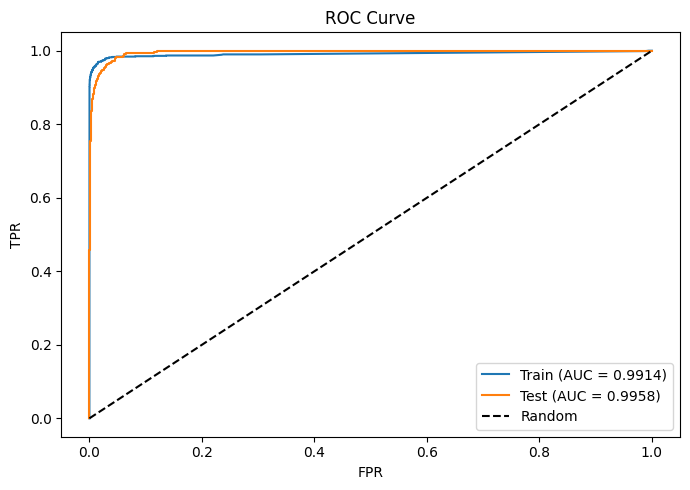

In [9]:
rf = RandomForestClassifier(max_depth=10, oob_score=True, random_state=42,  n_jobs=-1)
rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
y_train_proba = rf.predict_proba(X_train)[:, 1]
y_test_proba = rf.predict_proba(X_test)[:, 1]

conf_matrix_train = confusion_matrix(y_train, y_train_pred)
print(f"Confusion Matrix (Train Set): \n {conf_matrix_train}")

train_err_rf = 1 - accuracy_score(y_train, y_train_pred)
print(f"Train Error:: {train_err_rf:.4f}")

train_auc = roc_auc_score(y_train, y_train_proba)
print(f"AUC (Train Set): {train_auc:.4f}")
train_fpr, train_tpr, thresh = roc_curve(y_train, y_train_proba)

print("----"*25)
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
print(f"Confusion Matrix (Test Set): \n {conf_matrix_test}")

test_err_rf = 1 - accuracy_score(y_test, y_test_pred)
print(f"Test Error: {test_err_rf:.4f}")
oob_err_rf = 1 - rf.oob_score_
print(f"OOB Error : {oob_err_rf:.4f}")

test_auc = roc_auc_score(y_test,  y_test_proba)
print(f"AUC (Test Set): {test_auc:.4f}")
test_fpr, test_tpr, thresh = roc_curve(y_test,  y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(train_fpr, train_tpr, label=f'Train (AUC = {train_auc:.4f})')
plt.plot(test_fpr, test_tpr, label=f'Test (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

### (d) Fix class imbalance in random forest and compare to the results for imbalanced tree

Source: https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/

- **Class Weighting:** Assign higher misclassification penalty to the minority class inversely proportional to its frequency, forcing the model to pay more attention to APS failures during training.

- **Random Undersampling:** Randomly remove instances from the majority class to achieve a balanced class distribution before training.


Confusion Matrix (Train Set): 
 [[57938  1062]
 [   13   987]]
Train Error: 0.0179
AUC (Train Set): 0.9971
----------------------------------------------------------------------------------------------------
Confusion Matrix (Test Set): 
 [[15330   295]
 [   35   340]]
Test Error: 0.0206
OOB Error : 0.0210
AUC (Test Set): 0.9908


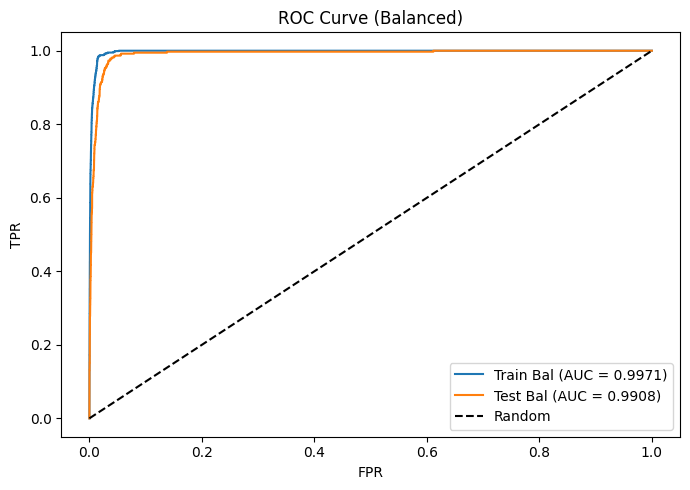

In [10]:
rf_bal = RandomForestClassifier(max_depth=10, class_weight='balanced', oob_score=True, random_state=42, n_jobs=-1)
rf_bal.fit(X_train, y_train)

y_train_pred_bal = rf_bal.predict(X_train)
y_test_pred_bal = rf_bal.predict(X_test)
y_train_proba_bal = rf_bal.predict_proba(X_train)[:, 1]
y_test_proba_bal = rf_bal.predict_proba(X_test)[:, 1]


conf_matrix_train_bal = confusion_matrix(y_train, y_train_pred_bal)
print(f"Confusion Matrix (Train Set): \n {conf_matrix_train_bal}")

train_err_rf_bal = 1 - accuracy_score(y_train, y_train_pred_bal)
print(f"Train Error: {train_err_rf_bal:.4f}")

train_auc_bal = roc_auc_score(y_train, y_train_proba_bal)
print(f"AUC (Train Set): {train_auc_bal:.4f}")
train_fpr_bal, train_tpr_bal, thresh = roc_curve(y_train, y_train_proba_bal)

print("----"*25)

conf_matrix_test_bal = confusion_matrix(y_test, y_test_pred_bal)
print(f"Confusion Matrix (Test Set): \n {conf_matrix_test_bal}")

test_err_rf_bal = 1 - accuracy_score(y_test, y_test_pred_bal)
print(f"Test Error: {test_err_rf_bal:.4f}")

oob_err_rf_bal = 1 - rf_bal.oob_score_
print(f"OOB Error : {oob_err_rf_bal:.4f}")

test_auc_bal = roc_auc_score(y_test,  y_test_proba_bal)
print(f"AUC (Test Set): {test_auc_bal:.4f}")
test_fpr_bal, test_tpr_bal, _ = roc_curve(y_test,  y_test_proba_bal)

plt.figure(figsize=(7, 5))
plt.plot(train_fpr_bal, train_tpr_bal, label=f'Train Bal (AUC = {train_auc_bal:.4f})')
plt.plot(test_fpr_bal,  test_tpr_bal,  label=f'Test Bal (AUC = {test_auc_bal:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve (Balanced)')
plt.legend()
plt.tight_layout()
plt.show()

#### Comparison
- I first ran Random Forest for both (c) and (d) with no maximum depth restriction, so both models grew trees until all leaves were pure, causing complete memorization of the training data. The uncompensated RF achieved a test AUC of 0.9937 and the class-weighted RF achieved 0.9873, however the uncompensated model missed 103 faulty trucks (FN) and the balanced model missed 171. The unlimited depth models overfit to the majority class patterns, producing unstable and unreliable fault detection.

- So we set max_depth=10 for Random Forest and achieved different results that better illustrate the point of the homework. The class-weighted model dramatically reduced FN from 121 to just 35, detecting far more faulty trucks at the cost of more false alarms (295 vs 17). In this setting with restsrtion on depth the **class-weighted model is clearly superior**.


### (e) XGBoost with L1-Penalized Logistic Regression and Cross-Validation

Optimal Lambda: 0.233572  with  CV Error: 0.0057
Confusion Matrix (Train Set):
 [[59000     0]
 [    1   999]]
Train Error: 0.0000
AUC (Train Set): 1.0000
----------------------------------------------------------------------------------------------------
Confusion Matrix (Test Set):
 [[15603    22]
 [   89   286]]
Test Error: 0.0069
CV Error: 0.0057
AUC (Test Set): 0.9946


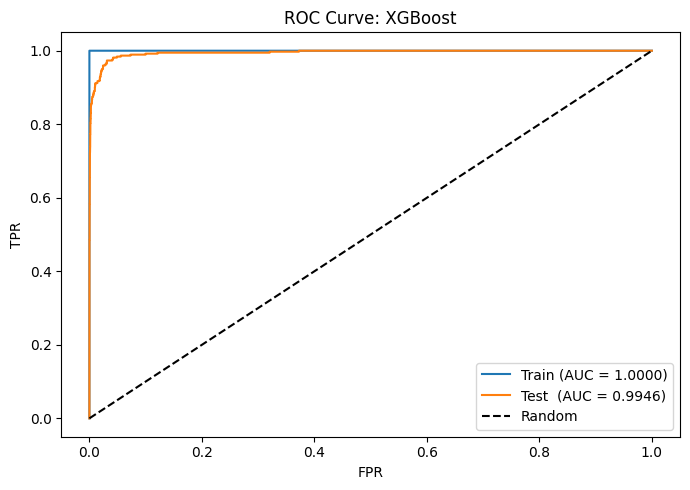

In [11]:
lambdas  = np.logspace(-4, 4, 20)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_err = {}

for lam in lambdas:
    xgb_models = xgb.XGBClassifier(reg_alpha=lam, objective='binary:logistic', max_depth=10, random_state=42, eval_metric='logloss', n_jobs=-1)
    scores = cross_val_score(xgb_models, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_err[lam] = 1 - scores.mean()
lambda_star = min(cv_err, key=cv_err.get)
print(f"Optimal Lambda: {lambda_star:.6f}  with  CV Error: {cv_err[lambda_star]:.4f}")

xgb_final = xgb.XGBClassifier(reg_alpha=lambda_star, objective='binary:logistic', max_depth=10, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_final.fit(X_train, y_train)

y_train_pred_xgb = xgb_final.predict(X_train)
y_test_pred_xgb = xgb_final.predict(X_test)
y_train_proba_xgb = xgb_final.predict_proba(X_train)[:, 1]
y_test_proba_xgb = xgb_final.predict_proba(X_test)[:, 1]

print(f"Confusion Matrix (Train Set):\n {confusion_matrix(y_train, y_train_pred_xgb)}")
train_err_xgb = 1 - accuracy_score(y_train, y_train_pred_xgb)
train_auc_xgb = roc_auc_score(y_train, y_train_proba_xgb)
print(f"Train Error: {train_err_xgb:.4f}" )
print(f"AUC (Train Set): {train_auc_xgb:.4f}")
train_fpr_xgb, train_tpr_xgb, _ = roc_curve(y_train, y_train_proba_xgb)

print("----"*25)
print(f"Confusion Matrix (Test Set):\n {confusion_matrix(y_test, y_test_pred_xgb)}")
test_err_xgb = 1 - accuracy_score(y_test, y_test_pred_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)
print(f"Test Error: {test_err_xgb:.4f}")
print(f"CV Error: {cv_err[lambda_star]:.4f}")
print(f"AUC (Test Set): {test_auc_xgb:.4f}")
test_fpr_xgb, test_tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)

plt.figure(figsize=(7, 5))
plt.plot(train_fpr_xgb, train_tpr_xgb, label=f'Train (AUC = {train_auc_xgb:.4f})')
plt.plot(test_fpr_xgb,  test_tpr_xgb,  label=f'Test  (AUC = {test_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve: XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

### (f) XGBoost with L1-Penalized Logistic Regression, Cross-Validation and SMOTE

/Users/alexanderrom/.virtualenvs/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Optimal Lambda (SMOTE): 0.000264  with  CV Error: 0.0065
Confusion Matrix (Train Set):
 [[59000     0]
 [    0  1000]]
Train Error: 0.0000
AUC (Train Set): 1.0000
----------------------------------------------------------------------------------------------------
Confusion Matrix (Test Set):
 [[15375   250]
 [   51   324]]
Test Error : 0.0188
CV Error: 0.0065
AUC (Test Set): 0.9903


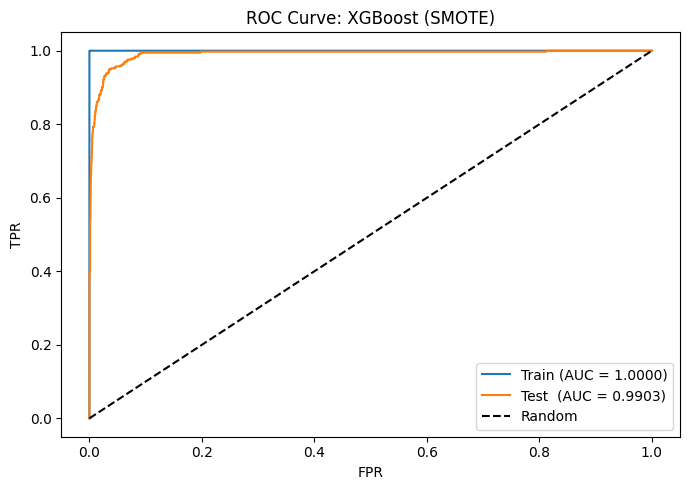

In [12]:
lambdas = np.logspace(-4, 4, 20)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_err_smote = {}

for lam in lambdas:
    xgb_pipe = Pipeline([ ('smote', SMOTE(random_state=42)),
                            ('xgb', xgb.XGBClassifier(reg_alpha=lam, objective='binary:logistic', max_depth=10, random_state=42, eval_metric='logloss', n_jobs=-1))])
    scores_smote = cross_val_score(xgb_pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_err_smote[lam] = 1 - scores_smote.mean()

lambda_star_smote = min(cv_err_smote, key=cv_err_smote.get)
print(f"Optimal Lambda (SMOTE): {lambda_star_smote:.6f}  with  CV Error: {cv_err_smote[lambda_star_smote]:.4f}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

xgb_final_smote = xgb.XGBClassifier(reg_alpha=lambda_star_smote, objective='binary:logistic', max_depth=10, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_final_smote.fit(X_train_smote, y_train_smote)

y_train_pred_xgb_smote = xgb_final_smote.predict(X_train)
y_test_pred_xgb_smote = xgb_final_smote.predict(X_test)
y_train_proba_xgb_smote = xgb_final_smote.predict_proba(X_train)[:, 1]
y_test_proba_xgb_smote = xgb_final_smote.predict_proba(X_test)[:, 1]

print(f"Confusion Matrix (Train Set):\n {confusion_matrix(y_train, y_train_pred_xgb_smote)}")
train_err_xgb_smote = 1 - accuracy_score(y_train, y_train_pred_xgb_smote)
train_auc_xgb_smote = roc_auc_score(y_train, y_train_proba_xgb_smote)
print(f"Train Error: {train_err_xgb_smote:.4f}")
print(f"AUC (Train Set): {train_auc_xgb_smote:.4f}")
train_fpr_xgb_smote, train_tpr_xgb_smote, _ = roc_curve(y_train, y_train_proba_xgb_smote)

print("----"*25)
print(f"Confusion Matrix (Test Set):\n {confusion_matrix(y_test, y_test_pred_xgb_smote)}")
test_err_xgb_smote = 1 - accuracy_score(y_test, y_test_pred_xgb_smote)
test_auc_xgb_smote = roc_auc_score(y_test, y_test_proba_xgb_smote)
print(f"Test Error : {test_err_xgb_smote:.4f}")
print(f"CV Error: {cv_err_smote[lambda_star_smote]:.4f}")
print(f"AUC (Test Set): {test_auc_xgb_smote:.4f}")
test_fpr_xgb_smote, test_tpr_xgb_smote, _ = roc_curve(y_test, y_test_proba_xgb_smote)

plt.figure(figsize=(7, 5))
plt.plot(train_fpr_xgb_smote, train_tpr_xgb_smote, label=f'Train (AUC = {train_auc_xgb_smote:.4f})')
plt.plot(test_fpr_xgb_smote,  test_tpr_xgb_smote,  label=f'Test  (AUC = {test_auc_xgb_smote:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve: XGBoost (SMOTE)')
plt.legend()
plt.tight_layout()
plt.show()

#### Comparison
Uncompensated XGBoost achieved a higher AUC of 0.9946 compared to 0.9903, and a lower test error of 0.0069 compared to 0.0188, however it missed 89 faulty trucks (FN) compared to only 51 with SMOTE. Hence, SMOTE significantly improved fault detection at the cost of more false alarms (250 vs 22). Thus, despite lower overall accuracy, the SMOTE model is superior under a real world scenario.

### References:

- https://mike-data-analysis.share.connect.posit.cloud/methods-for-handling-missing-data.html
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/
- https://xgboost.readthedocs.io/en/latest/python/python_api.html
- https://www.geeksforgeeks.org/machine-learning/xgbclassifier/
- https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
- https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html
- https://scikit-learn.org/stable/modules/svm.html
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html